In [12]:
import langgraph
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [13]:
load_dotenv()
import os
key = os.getenv("gemini_api")

In [14]:
import langchain_google_genai 
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=key,
    temperature=0.7
)

In [17]:
class SentimentSchema(BaseModel):
    senti:bool = Field(description='Based on the text identify the sentiment if it is positive then true else false')

In [18]:
s_model = model.with_structured_output(SentimentSchema)

In [19]:
class DiagnosisSchema(BaseModel):
    issue_type:str = Field(description='Based on the review categorize the issue like software issue,ui issue.')
    tone:str =Field(description= "Based on the review identify the tone of the customer like frustration or anger or any other mention one")
    urgency:str =  Field(description= "Based on the review identify the urgency")

In [20]:
d_model = model.with_structured_output(DiagnosisSchema)

In [9]:
prompt = "Absolutely terrible experience. My phone screen has a serious issue and it needs immediate repair, but there has been zero urgency from the service team. This is not a minor inconvenience—it's affecting my daily work. Extremely disappointed with the lack of response."

In [22]:
out

DiagnosisSchema(issue_type='Hardware issue', tone='Frustration and Disappointment', urgency='High')

# State

In [21]:
class RState(TypedDict):
    review:str
    senti:bool
    issue_type:str
    tone:str
    urgency:str

    pos_reply:str
    neg_reply:str

# Utility

In [22]:
def check_senti(state:RState):
    rev = state['review']
    sentiment = s_model.invoke(rev).senti 
    return {'senti':sentiment}

def router(state:RState)->Literal["pos_reply","run_diagnosis"]:
    senti = state['senti']

    if senti == True:
        return "pos_reply"
    else :
        return "run_diagnosis"


def pos_reply(state:RState):
    prompt = f"the customer has given this positive feedback \n {state['review']}\n So give a reply in kind manner"
    out = model.invoke(prompt).content
    return {"pos_reply":out}

def run_diagnosis(state:RState):
    out = d_model.invoke(state['review'])
    return {'issue_type':out.issue_type,'tone':out.tone,'urgency':out.urgency}

def neg_reply(state:RState):
    prompt= f"Based on the review,{state['review']}\n issue type->{state['issue_type']} urgency->{state['urgency']} and tone ->{state['tone']}\n give a proper response" 
    out = model.invoke(prompt).content
    return {'neg_reply':out}

# Graph

In [23]:
graph = StateGraph(RState)

graph.add_node('check_senti',check_senti)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('pos_reply',pos_reply)
graph.add_node('neg_reply',neg_reply)

graph.add_edge(START,'check_senti')
graph.add_conditional_edges('check_senti',router)
graph.add_edge('run_diagnosis','neg_reply')
graph.add_edge('neg_reply',END)
graph.add_edge('pos_reply',END)

wf = graph.compile()

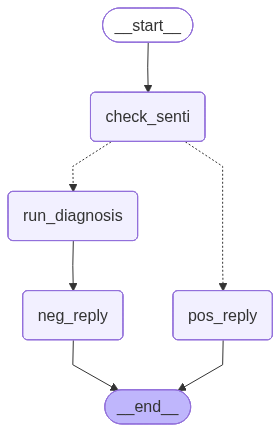

In [24]:
wf

# Testing

In [25]:
prompt = "Absolutely terrible experience. My phone screen has a serious issue and it needs immediate repair, but there has been zero urgency from the service team. This is not a minor inconvenience—it's affecting my daily work. Extremely disappointed with the lack of response."

In [26]:
init = {'review':prompt}
out = wf.invoke(init)

In [27]:
out

{'review': "Absolutely terrible experience. My phone screen has a serious issue and it needs immediate repair, but there has been zero urgency from the service team. This is not a minor inconvenience—it's affecting my daily work. Extremely disappointed with the lack of response.",
 'senti': False,
 'issue_type': 'Hardware issue',
 'tone': 'Frustration and Disappointment',
 'urgency': 'High',
 'neg_reply': "I'm so sorry to hear about your absolutely terrible experience and the serious issue with your phone screen. I sincerely apologize for the lack of urgency and response you've received from our service team.\n\nI completely understand how critical a functioning phone is for your daily work, and that this isn't just a minor inconvenience, but a significant disruption. Your frustration and disappointment are entirely justified.\n\nThis is definitely a high-priority hardware issue, and we need to address it immediately. We want to rectify this situation as quickly as possible.\n\nTo help